In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
Ks = np.load("9d9f_Ks.npy")
lag_times = range(1, 301) # 1 frame = 2 ps
basis_list = np.array([[[-1.0939795878279368, 2], [0.6151525780598074, 2], [0.6025909988440169, 2], [-0.9219408339178378, 2]], [[-1.0939795878279368, 2], [0.6151525780598074, 2], [0.6025909988440169, 2], [-0.9219408339178378, 2]]])
print(Ks.shape)

(300, 25, 25)


Time = 1 ps
[129.58887188604098, 12.060516105962474, 5.1321750202900205, 3.188149100422746, 2.6173981305822247]
Time = 2 ps
[171.54323036584574, 16.17615470136462, 6.822884745542547, 4.350125517091048, 3.588804280895245]
Time = 3 ps
[200.1216369948689, 18.98586236225116, 8.047159465198462, 5.159872740727489, 4.311464011319565]
Time = 4 ps
[221.78680845347142, 21.1167262524762, 9.020322932082848, 5.7955185805334954, 4.918346854524301]
Time = 5 ps
[238.9121544611986, 22.828798042195086, 9.848308731331073, 6.342438196203934, 5.465515604375678]
Time = 6 ps
[253.10064744377092, 24.257910208562546, 10.579001358949492, 6.813300522437953, 5.951984389022556]
Time = 7 ps
[265.0218788604805, 25.453440001459168, 11.225177452852552, 7.234174126674755, 6.400205894434481]
Time = 8 ps
[275.4389792810564, 26.50979679048366, 11.833086529737555, 7.6123829484808425, 6.833126551784874]
Time = 9 ps
[284.65217448415655, 27.45974523528053, 12.384495737549003, 7.991079551818606, 7.248835633323741]
Time = 10 ps

ITS.shape = (5, 300)


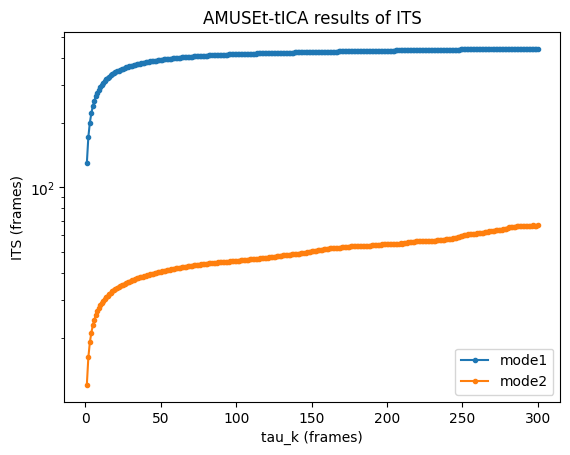

Current date and time: 2026-03-28 23:09:49.002062


In [3]:
ITSs, Es, Vs = [], [], []
for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", lag_times[i], 'ps')
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(2):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 
plt.xlabel('tau_k (frames)')
plt.ylabel('ITS (frames)')
plt.title('AMUSEt-tICA results of ITS')
plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [5]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


# regression: tau_k&L, RMSE

In [6]:
def compute_rmse(diff):
    return np.sqrt(np.square(np.mean(diff)) + np.square(np.std(diff)))

RMSE_rec = np.array([[-1.] * 100 for _ in range(100)])
list_plot = [[], [], []]

rmse_steps = 200
for st in range(1, 71):
    for en in range(st+5, 90):
        M_hat, info = fit_M_from_K_sequence(Ks[:en], st, 1, enforce_hermitian_M=False)
        #print_regression_summary(info)
        A_hat = fit_A_from_K0_and_M(Ks[st], M_hat)
        Ks_model = generate_K_from_A_M(A_hat, M_hat, rmse_steps+en-st)
        
        RMSE_rec[st][en] = compute_rmse(Ks_model[en-st:]-Ks[en:rmse_steps+en])
        list_plot[0].append(st)
        list_plot[1].append(en-st)
        list_plot[2].append(RMSE_rec[st][en])
        # Optional: uncertainties
        #Ms_boot, M_mean, M_std = bootstrap_M(Ks, n_boot=200, random_state=0)


In [15]:
arr = np.array(list_plot[2])
idx = np.unravel_index(np.argmin(arr), arr.shape)[0]
print(idx, list_plot[2][idx])
print(list_plot[0][idx], list_plot[1][idx])

3373 0.0008094219938155013
65 18


In [9]:
A = np.array(list_plot[2])
thr = np.percentile(A, 1)

idx = np.where(A <= thr)
print(idx[0])
print([(list_plot[0][_],list_plot[1][_]) for _ in idx[0]])

[2732 2733 3352 3353 3356 3357 3358 3359 3371 3372 3373 3374 3375 3376
 3377 3378 3379 3392 3395 3396 3397 3398 3409 3410 3413 3414 3415 3416
 3430 3431 3432 3447 3461 3462 3463]
[(44, 28), (44, 29), (64, 18), (64, 19), (64, 22), (64, 23), (64, 24), (64, 25), (65, 16), (65, 17), (65, 18), (65, 19), (65, 20), (65, 21), (65, 22), (65, 23), (65, 24), (66, 17), (66, 20), (66, 21), (66, 22), (66, 23), (67, 15), (67, 16), (67, 19), (67, 20), (67, 21), (67, 22), (68, 18), (68, 19), (68, 20), (69, 18), (70, 16), (70, 17), (70, 18)]


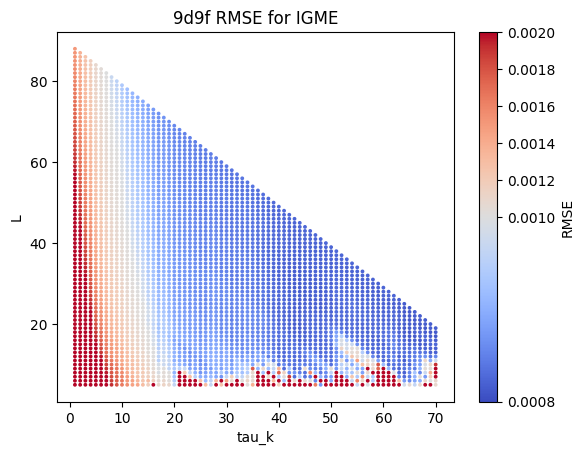

In [16]:
import matplotlib.colors as colors

norm = colors.TwoSlopeNorm(vmin=.0008, vcenter=.001, vmax=.002)
plt.scatter(list_plot[0], list_plot[1], s=3, c=list_plot[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.title('9d9f RMSE for IGME')
plt.show()

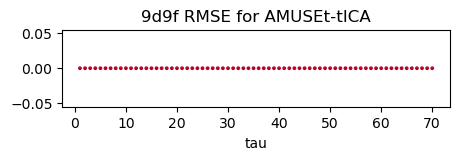

0.016797146804828477 0.05223081917146683


In [28]:
rmse_AT = []
for i in range(1, 71):
    ed = int(rmse_steps/i)
    this_Ks_seq = [Ks[i]]
    orig_Ks_seq = [Ks[i]]
    for j in range(ed):
        this_Ks_seq.append(Ks[i] @ this_Ks_seq[-1])
        orig_Ks_seq.append(Ks[j*i])
    this_rmse = ((np.mean((np.array(this_Ks_seq)-np.array(orig_Ks_seq))**2))**0.5)
    rmse_AT.append(this_rmse)
    
plt.figure(figsize=(5,1))
norm = colors.TwoSlopeNorm(vmin=.0008, vcenter=.001, vmax=.002)
plt.scatter(range(1, 71), [0]*70, s=3, c=rmse_AT, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('9d9f RMSE for AMUSEt-tICA')
plt.show()
print(np.min(rmse_AT), np.max(rmse_AT))

In [25]:
list_plot = np.array(list_plot)
norm_lim = [.0008, .001, .002]
usage = '''norm = colors.TwoSlopeNorm(vmin=.0008, vcenter=.001, vmax=.002)
plt.scatter(data[0], data[1], s=3, c=data[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.title('9d9f RMSE for IGME')
plt.show()'''

In [19]:
np.savez('Panel_1e1_RMSE.npz', data=list_plot, norm=norm_lim, title='9d9f RMSE for IGME', usage = usage)

In [26]:
AT_usage = '''plt.figure(figsize=(5,1))
norm = colors.TwoSlopeNorm(vmin=.0008, vcenter=.001, vmax=.002)
plt.scatter(range(1, 71), [0]*70, s=3, c=rmse_AT, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('9d9f RMSE for AMUSEt-tICA')
plt.show()'''

np.savez('Panel_1e2_RMSE.npz', data=rmse_AT, norm=norm_lim, title='9d9f RMSE for AMUSEt-tICA', usage = AT_usage)